In [1]:
FW_DIR = "../fw/examples/simpleserial_example"
BIN_FILE = f"{FW_DIR}/simpleserial_example.bin"
BOOTLOADER = "python3 ../../sdk/toolchain/bootloader.py"
BS_FILE = "../vivado/risqrypt_cw305.runs/impl_1/fpga_top.bit"

In [2]:
import sys
sys.path.insert(0, "../")

from host.CW305_rq import CW305_rq

In [3]:
import chipwhisperer as cw
scope = cw.scope()
scope.adc.offset = 0
scope.adc.basic_mode = "rising_edge"
scope.trigger.triggers = "tio4"
scope.io.tio1 = "serial_rx"
scope.io.tio2 = "serial_tx"
scope.io.hs2 = "disabled"

In [4]:
TARGET_PLATFORM = 'CW305_100t'

In [5]:
platform = 'cw305'
fpga_id = '100t'

target = cw.target(scope, CW305_rq, force=True, fpga_id=fpga_id, platform=platform, bsfile=BS_FILE)

(ChipWhisperer NAEUSB WARNING|File naeusb.py:800) Your firmware (0.51) is outdated - latest is 0.53 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


In [6]:
target.vccint_set(1.0)
# we only need PLL1:
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(False, 0)
target.pll.pll_outenable_set(True, 1)
target.pll.pll_outenable_set(False, 2)

# run at 10 MHz:
target.pll.pll_outfreq_set(20E6, 1)

# 1ms is plenty of idling time
target.clkusbautooff = True
target.clksleeptime = 1

In [8]:
%%bash -s "$FW_DIR"
cd $1
make

-DSS_VER=1 -O0 -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o simpleserial_example.elf
/opt/riscv/bin/riscv64-unknown-elf-gcc simpleserial_example.c ../../driver/cw305.c ../../simpleserial/simpleserial.c ../../../../sdk/toolchain/start.s ../../../../sdk/lib/util.c ../../../../sdk/lib/uart.c ../../../../sdk/lib/timer.c ../../../../sdk/lib/gpio.c ../../../../sdk/lib/keccak.c ../../../../sdk/lib/ntt_lite.c ../../../../sdk/lib/x2x.c -DSS_VER=1 -O0 -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o simpleserial_example.elf
/opt/riscv/bin/riscv64-unknown-elf-objcopy -O binary -j .init -j .text -j .rodata -j .data simpleserial_example.elf simpleserial_example.bin
python3 ../../../../sdk/toolchain/rom_g

In [9]:
%%bash -s "$BIN_FILE" "$BOOTLOADER"
$2 -f $1 -q

Successfully connected to /dev/ttyUSB0
Sent: -p
Waiting for opcodes...
Sending file: ../fw/examples/simpleserial_example/simpleserial_example.bin


../fw/examples/simpleserial_example/simpleserial_example.bin: 100%|██████████| 61.5k/61.5k [01:03<00:00, 972B/s]  


File transmission complete.
Serial port closed.


In [7]:
if scope._is_husky:
    scope.clock.clkgen_freq = 40e6
    scope.clock.clkgen_src = 'extclk'
    scope.clock.adc_mul = 2
    # if the target PLL frequency is changed, the above must also be changed accordingly
else:
    scope.clock.adc_src = "extclk_x4"

In [8]:
import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

In [9]:
scope.adc.samples = 500
scope.gain.db = 20

In [10]:
target.output_len = 16

In [11]:
from tqdm.notebook import tnrange
import numpy as np
import estraces
import time

ktp = cw.ktp.Basic()

N = 1000  # Number of traces

# initialize cipher to verify DUT result:
key, text = ktp.next()
target.simpleserial_write('k', key, end='\n')
target.simpleserial_wait_ack()
# target.set_key(key, always_send=True, ack=True)

traces = []
textin = []
keys = []

for i in tnrange(N, desc='Capturing traces'):
    # run aux stuff that should come before trace here

    key, text = ktp.next()  # manual creation of a key, text pair can be substituted here
    textin.append(text)
    keys.append(key)
    
    ret = cw.capture_trace(scope, target, text, None)
    if not ret:
        print("Failed capture")
        continue

    textout_cw = cw.bytearray(ret.textout)
    for i in range(16):
        assert textout_cw[i] == ((key[i] + text[i]) % 256), f"mismatch at index {i}"
        
    traces.append(ret.wave)


ths = estraces.read_ths_from_ram(np.array(traces), k=np.array(keys), p=np.array(textin))

print(ths)

Capturing traces:   0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [17]:
print(ths)

Trace Header Set:
Name.............: RAM Format THS
Reader...........: RAM reader with 1000 traces. Samples shape: (1000, 500) and metadatas: ['k', 'p']
k................: uint8
p................: uint8



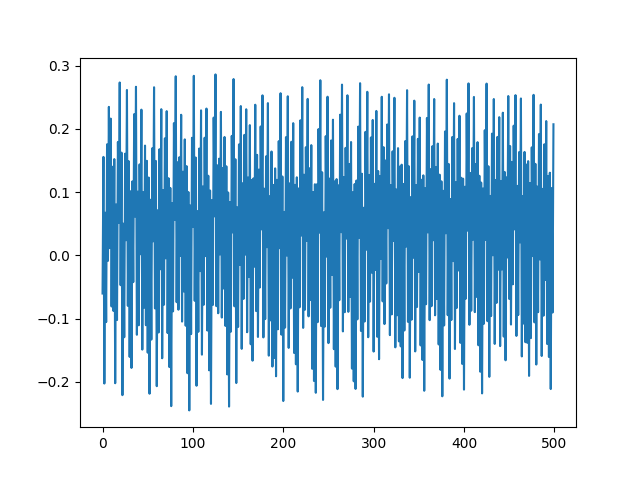

In [15]:
from matplotlib import pyplot as plt

%matplotlib widget

mean_trace = np.mean(np.array(traces), axis=0)
plt.plot(mean_trace)

In [16]:
from matplotlib import pyplot as plt

for i in range(5):
    plt.plot(traces[i])

In [19]:
import scared

@scared.reverse_selection_function
def select(k, p):
    return k + p


cpa_reverse = scared.CPAReverse(selection_function=select, model=scared.HammingWeight(expected_dtype='uint8'))


container = scared.Container(ths)
cpa_reverse.run(container)


In [20]:
cpa_reverse.results.shape

(16, 500)

/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


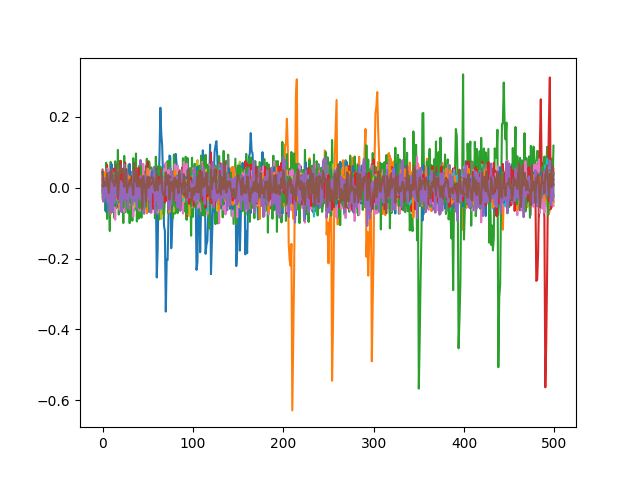

In [21]:
fig, ax = plt.subplots()

for i in range(16):
    ax.plot(cpa_reverse.results[i])